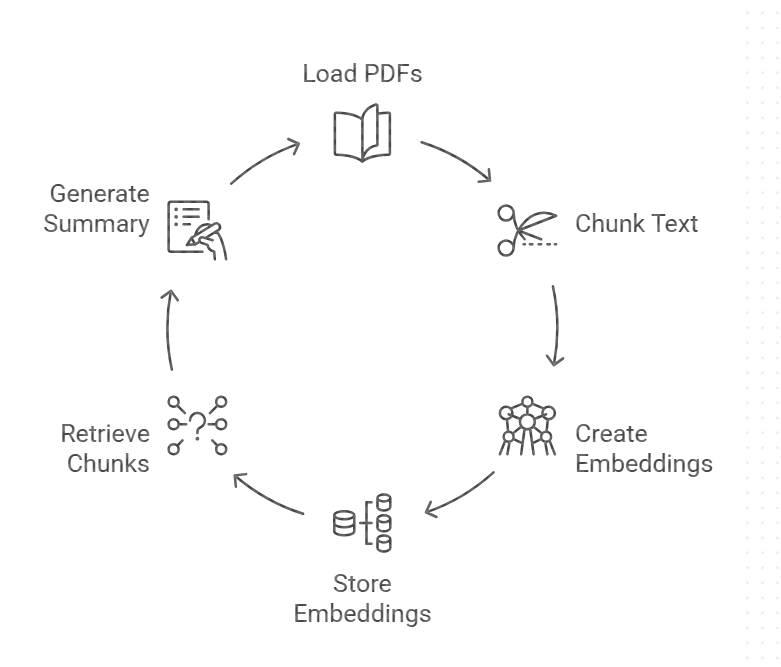

# Python Packages Used in This Notebook

- **langchain**: The core library for developing applications powered by large language models. It provides tools for chaining together different components to create more complex applications.  
- **langchain-community**: Contains third-party integrations and utilities that extend LangChain's capabilities, often for connecting to various data sources, models, or services.  
- **langchain-google-genai**: Integration that allows LangChain to work with Google's Generative AI models.  
- **langchain-text-splitters**: Essential for breaking down large documents into smaller, manageable chunks, which is crucial for efficient processing by language models and vector databases.  
- **pypdf**: A library for working with PDF files, used to load document content from PDFs.  
- **google-generativeai**: The official Python SDK for Google's Generative AI services.  
- **pinecone-client**: The official client library for interacting with the Pinecone vector database, which stores and retrieves vector embeddings.  
- **langchain-pinecone**: Integration that allows LangChain to easily work with Pinecone as a vector store.  
- **sentence-transformers**: A library specifically designed for generating high-quality sentence embeddings, which are numerical representations of text that capture semantic meaning.


In [36]:
!pip -q install langchain \
langchain-community \
pypdf \
langchain-text-splitters \
sentence-transformers \
 pinecone-client \
 google-generativeai

Import all required libraries

In [38]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from pinecone import Pinecone, ServerlessSpec
from google.colab import drive
from google.colab import userdata
import google.generativeai as genai
import os

# API Keys Setup Guide
## 1 Google API Key

1. Go to: **Google Cloud Console**  
   https://console.cloud.google.com/
2. Create **New Project**
3. Go to **APIs & Services → Library**
4. Enable required API (e.g., Generative Language API)
5. Go to **Credentials → Create Credentials → API Key**
6. Copy the key

---

## 2 Hugging Face Token

1. Go to: **Hugging Face**  
   https://huggingface.co/
2. Login → Profile → **Settings**
3. Go to **Access Tokens**
4. Click **New Token**
5. Select role (`Read` / `Write`)
6. Generate and copy token

---

##3 Pinecone API Key

1. Go to: **Pinecone Console**  
   https://app.pinecone.io/
2. Login → Dashboard
3. Go to **API Keys**
4. Create new key
5. Copy API key + environment

---
## 4 Add to collab secrets

1. Open your notebook in **Google Colab**
2. Click the **Secrets** icon (left sidebar)
3. Click **+ Add new secret**
4. Add:
   - Name: `GOOGLE_API_KEY`
   - Value: your actual key
5. Enable **“Notebook access”**





In [39]:
PINECONE_API_KEY = userdata.get('Pinecone_API')
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
HF_TOKEN = userdata.get('HF_token')

os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN
os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [ ]:
#already mounted, so commented the code.
#drive.mount('/content/drive')

In [41]:
loader = PyPDFDirectoryLoader("/content/drive/MyDrive/VectorDB_docs/")
documents = loader.load()
print(f"Loaded {len(documents)} documents")

Loaded 4 documents


Why This Is Critical

Without chunking:

*  Embeddings become too large
*  Retrieval becomes inaccurate
*  LLM misses relevant context

In [43]:
def chunk_data(docs, chunk_size=900, chunk_overlap=100):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    return splitter.split_documents(docs)

chunks = chunk_data(documents)

print(type(chunks[0])) # this was added to check if data tyoe is not tuple and is a document to be parsed to vector DB
print(f"Created {len(chunks)} chunks")

<class 'langchain_core.documents.base.Document'>
Created 16 chunks


In [44]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

texts = [c.page_content for c in chunks]

vectors = model.encode(
    texts,
    batch_size=32,
    normalize_embeddings=True
).tolist()

print("Embedding dimension:", len(vectors[0]))

Embedding dimension: 384


In [47]:

pc = Pinecone(api_key=PINECONE_API_KEY)

INDEX_NAME = "hf-langchainvectordb"

if INDEX_NAME not in [i.name for i in pc.list_indexes()]:
    pc.create_index(
        name=INDEX_NAME,
        dimension=384,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )
else:
  print("Index already exist")

index = pc.Index(INDEX_NAME)
print("Pinecone ready")

Index already exist
Pinecone ready


In [48]:
to_upsert = []

for i, doc in enumerate(chunks):
    metadata = doc.metadata.copy()
    metadata["text"] = doc.page_content  # ⭐ REQUIRED FOR RAG

    to_upsert.append((f"id_{i}", vectors[i], metadata))

# batch upsert for safety
batch_size = 100
for i in range(0, len(to_upsert), batch_size):
    index.upsert(vectors=to_upsert[i:i+batch_size])

print(f"Uploaded {len(to_upsert)} chunks")

Uploaded 16 chunks


In [49]:
query_text = "Summarize the health insurance policy details"

query_vector = model.encode(
    query_text,
    normalize_embeddings=True
).tolist()

results = index.query(
    vector=query_vector,
    top_k=5,
    include_metadata=True
)

print("Retrieved matches:", len(results["matches"]))

Retrieved matches: 5


In [55]:
# query_text = "Is there any way to enrol during the mid of the year"

# query_vector = model.encode(
#     query_text,
#     normalize_embeddings=True
# ).tolist()

# results = index.query(
#     vector=query_vector,
#     top_k=5,
#     include_metadata=True
# )

# print("Retrieved matches:", len(results["matches"]))

Retrieved matches: 5


In [56]:
context = "\n\n".join([
    match["metadata"]["text"]
    for match in results["matches"]
])

print(context[:500])

Applicable only for newly wedded spouse & new-born child. Existing dependents 
cannot be enrolled midway through the policy period. Employees should enrol 
new-born baby/newly wedded spouse within  30 Days from the date of such 
events (date of marriage or date of birth), failing which employee  cannot add the 
new dependent till the next policy renewal

HAND BOOK FOR HEALTH INSURANCE POLICY                                   
 
 
   Client Name                                   Devon Software Se


In [59]:

# genai.configure(api_key=GOOGLE_API_KEY)

# gemini_model = genai.GenerativeModel("gemini-2.5-flash") #gemini-2.0-flash,gemini-2.0-flash

# # prevent context overflow
# context = context[:12000]

# prompt = f"""
# how mid term enrolment can happen:

# {context}
# """

# response = gemini_model.generate_content(prompt)

# print("\n  FINAL SUMMARY:\n")
# print(response.text)



  FINAL SUMMARY:

Based on the provided handbook, here's how mid-term enrolment can happen:

**Eligibility for Mid-Term Enrolment:**

*   Mid-term enrolment is **only applicable for:**
    *   Newly wedded spouse
    *   New-born child

**Restrictions:**

*   **Existing dependents cannot be enrolled midway** through the policy period.

**Timeline for Enrolment:**

*   Employees must enrol the new-born baby or newly wedded spouse **within 30 days** from the date of the event (date of marriage or date of birth).

**Consequence of Missing the Deadline:**

*   Failing to enrol within the 30-day window means the employee **cannot add the new dependent until the next policy renewal.**


In [57]:

genai.configure(api_key=GOOGLE_API_KEY)

gemini_model = genai.GenerativeModel("gemini-2.5-flash") #gemini-2.0-flash,gemini-2.0-flash

# prevent context overflow
context = context[:12000]

prompt = f"""
You are an insurance expert.

Provide a clear, concise summary of the following policy:

{context}
"""

response = gemini_model.generate_content(prompt)

print("\n  FINAL SUMMARY:\n")
print(response.text)



  FINAL SUMMARY:

Okay, here is a clear and concise summary of the Group Health Insurance policy for Devon Software Services Private Limited, from an insurance expert's perspective:

---

**Policy Summary: Devon Software Services Group Health Insurance (ICICI Lombard)**

This is a comprehensive Group Health Insurance policy underwritten by ICICI Lombard, managed by PolicyBazaar Insurance Brokers, effective from **January 25, 2026, to January 24, 2027.**

**Key Benefits & Coverage:**

1.  **Covered Members:** Employee, Spouse, 2 Dependent Children (up to 25 years), and Dependent Parents/Parents-in-law (up to 80 years).
2.  **Sum Insured (SI):** Options of INR 3,00,000 or INR 5,00,000 per family per policy period.
3.  **Significant Waivers:**
    *   **Pre-Existing Diseases (PED):** Covered from Day 1.
    *   **Waiting Periods:** All standard waiting periods (including the initial 30 days and 1/2/3/4 year waiting periods) are **waived off**.
    *   **Maternity Waiting Period:** The 9-